## Défi quotidien : Prédiction du cours des actions avec LSTM

Ce notebook vous guidera à travers la création et l'entraînement d'un modèle LSTM (Long Short-Term Memory) en utilisant PyTorch pour prédire le cours des actions.

### 1. Installation des bibliothèques requises

Nous allons installer les bibliothèques nécessaires pour cette tâche, notamment `torch`, `pandas`, `numpy`, `matplotlib`, `scikit-learn` et `yfinance` pour télécharger les données boursières.

In [ ]:
!pip install torch pandas numpy matplotlib scikit-learn yfinance

### 2. Chargement et prétraitement de l'ensemble de données

Nous allons télécharger des données boursières (par exemple, Apple - AAPL) en utilisant `yfinance`, supprimer les colonnes inutiles, créer une colonne cible pour le cours de clôture du lendemain, et normaliser les données à l'aide de `MinMaxScaler`.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Télécharger les données boursières (exemple: Apple - AAPL)
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2023-01-01")

# Afficher les 5 premières lignes du jeu de données
display(data.head())

# Utiliser seulement la colonne 'Close' pour la prédiction
data = data[['Close']]

# Créer la colonne cible (cours de clôture du lendemain)
data['Target'] = data['Close'].shift(-1)

# Supprimer la dernière ligne qui aura une valeur NaN pour 'Target'
data = data.dropna()

# Normaliser l'ensemble de données
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns, index=data.index)

display(data_scaled.head())

print(f"Forme des données après prétraitement : {data_scaled.shape}")

/tmp/ipykernel_9721/590894016.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2010-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406481,6.421150,6.357687,6.389119,493729600
2010-01-05,6.417556,6.453778,6.383729,6.424142,601904800
2010-01-06,6.315478,6.443003,6.308892,6.417558,552160000
2010-01-07,6.303802,6.346311,6.258001,6.338827,477131200
2010-01-08,6.345711,6.346310,6.258301,6.295420,447610800


Price,Close,Target
Ticker,AAPL,
Date,,
2010-01-04,-0.992364,-0.992236
2010-01-05,-0.992236,-0.993421
2010-01-06,-0.993421,-0.993557
2010-01-07,-0.993557,-0.993070
2010-01-08,-0.993070,-0.993721


Forme des données après prétraitement : (3271, 2)


### 3. Préparer l'ensemble de données pour l'entraînement

Nous allons diviser les données en ensembles d'entraînement, de validation et de test, puis créer une classe `Dataset` personnalisée PyTorch et des `DataLoader` pour gérer les données par lots.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# Fonction pour créer des séquences de données pour LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].values
        y = data.iloc[i + seq_length]['Target']
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60 # Longueur de la séquence d'entrée

x, y = create_sequences(data_scaled[['Close', 'Target']], seq_length)

# Séparer les données en ensembles d'entraînement, de validation et de test
train_size = int(len(x) * 0.8)
val_size = int(len(x) * 0.1)
test_size = len(x) - train_size - val_size

x_train, y_train = x[:train_size], y[:train_size]
x_val, y_val = x[train_size:train_size+val_size], y[train_size:train_size+val_size]
x_test, y_test = x[train_size+val_size:], y[train_size+val_size:]

# Convertir en tensors PyTorch
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()
x_val = torch.from_numpy(x_val).float()
y_val = torch.from_numpy(y_val).float()
x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test).float()

# Définir la classe Dataset personnalisée
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Créer les instances Dataset
train_dataset = StockDataset(x_train, y_train)
val_dataset = StockDataset(x_val, y_val)
test_dataset = StockDataset(x_test, y_test)

batch_size = 64

# Créer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Nombre de séquences d'entraînement : {len(train_dataset)}")
print(f"Nombre de séquences de validation : {len(val_dataset)}")
print(f"Nombre de séquences de test : {len(test_dataset)}")

Nombre de séquences d'entraînement : 2568
Nombre de séquences de validation : 321
Nombre de séquences de test : 322


### 4. Définition du modèle LSTM

Nous allons construire notre modèle LSTM en utilisant PyTorch. Le modèle comprendra une couche LSTM, une couche Dropout pour la régularisation, et une couche `Linear` pour la sortie.

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_rate=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialiser les états cachés et cellulaires
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Propager l'entrée à travers le LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Prendre la sortie de la dernière étape temporelle
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Définir les hyperparamètres du modèle
input_size = x_train.shape[2] # Nombre de features (Close, Target)
hidden_size = 128
num_layers = 2
output_size = 1
dropout_rate = 0.2

# Instancier le modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout_rate).to(device)

# Afficher l'architecture du modèle
print(model)

LSTMModel(
  (lstm): LSTM(2, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


### 5. Entraînement du modèle

Nous allons configurer l'optimiseur et la fonction de perte, puis mettre en place les boucles d'entraînement et de validation pour entraîner le modèle pendant un nombre spécifié d'époques.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([8, 1])) that is different to the input size (torch.Size([8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, targ

Epoch [1/50], Train Loss: 0.0933, Val Loss: 0.9158
Epoch [2/50], Train Loss: 0.0385, Val Loss: 1.0953
Epoch [3/50], Train Loss: 0.0396, Val Loss: 1.1634
Epoch [4/50], Train Loss: 0.0394, Val Loss: 1.0887
Epoch [5/50], Train Loss: 0.0380, Val Loss: 1.2519
Epoch [6/50], Train Loss: 0.0395, Val Loss: 1.1017
Epoch [7/50], Train Loss: 0.0397, Val Loss: 1.1914
Epoch [8/50], Train Loss: 0.0398, Val Loss: 1.2183
Epoch [9/50], Train Loss: 0.0380, Val Loss: 1.2057
Epoch [10/50], Train Loss: 0.0387, Val Loss: 1.2758
Epoch [11/50], Train Loss: 0.0377, Val Loss: 1.2037
Epoch [12/50], Train Loss: 0.0390, Val Loss: 1.1913
Epoch [13/50], Train Loss: 0.0399, Val Loss: 1.2052
Epoch [14/50], Train Loss: 0.0379, Val Loss: 1.2705
Epoch [15/50], Train Loss: 0.0381, Val Loss: 1.1816
Epoch [16/50], Train Loss: 0.0377, Val Loss: 1.2614
Epoch [17/50], Train Loss: 0.0377, Val Loss: 1.2773
Epoch [18/50], Train Loss: 0.0374, Val Loss: 1.2724
Epoch [19/50], Train Loss: 0.0389, Val Loss: 1.2261
Epoch [20/50], Train 

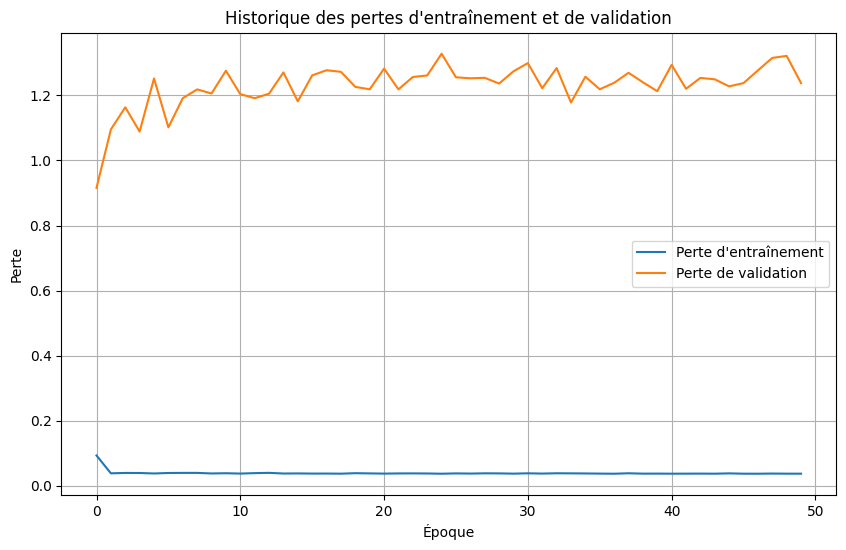

In [ ]:
import torch.optim as optim

# Configurer l'optimiseur et la fonction de perte
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

num_epochs = 50

# Listes pour stocker l'historique d'entraînement
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Boucle d'entraînement
    model.train()
    current_train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output.squeeze(), target)
        loss.backward()
        optimizer.step()

        current_train_loss += loss.item()

    avg_train_loss = current_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Boucle de validation
    model.eval()
    current_val_loss = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output.squeeze(), target)
            current_val_loss += loss.item()

    avg_val_loss = current_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

print("Entraînement terminé.")

# Tracer l'historique des pertes
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Perte d\'entraînement')
plt.plot(val_losses, label='Perte de validation')
plt.title('Historique des pertes d\'entraînement et de validation')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)
plt.show()

### 6. Évaluation du modèle

Enfin, nous allons évaluer les performances du modèle sur l'ensemble de test en calculant le score R² et en visualisant les prédictions par rapport aux valeurs réelles. Nous conserverons également l'objet `scaler` pour les futures dénormalisations.

In [ ]:
from sklearn.metrics import r2_score

# Évaluer le modèle sur l'ensemble de test
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        predictions.extend(output.squeeze().cpu().numpy())
        actuals.extend(target.cpu().numpy())

# Calculer le score R²
r2 = r2_score(actuals, predictions)
print(f"Score R² sur l'ensemble de test : {r2:.4f}")

# Dénormaliser les prédictions et les valeurs réelles pour une meilleure visualisation
# Il faut recréer un scaler pour la colonne 'Close' seulement si c'était la seule colonne utilisée pour l'entrée du modèle.
# Cependant, puisque nous avons utilisé 'Close' et 'Target' pour scaler, nous devons faire attention.

# Pour la dénormalisation, nous avons besoin de la forme originale de la colonne 'Close'.
# Le scaler a été ajusté sur ['Close', 'Target']. Donc pour inverser, il faut des données de la même forme.
# Créons des tableaux de la bonne forme pour la dénormalisation.

# Supposons que nous voulions dénormaliser 'Close' qui était la première colonne du scaler.
# Nous allons créer des 'faux' vecteurs pour la deuxième colonne (Target) car scaler.inverse_transform attend 2 colonnes.
# Une façon plus propre serait de scaler uniquement la colonne 'Close' si c'est la seule qui nous intéresse pour les prédictions.
# Pour simplifier ici, nous allons dénormaliser le 'Target' directement.

# Inverse la transformation pour les valeurs réelles et prédites (qui sont des cotes boursières)
# Le scaler a été entraîné sur un DataFrame avec deux colonnes ('Close', 'Target').
# Pour inverser une seule colonne de sortie, il faut créer une 'fausse' deuxième colonne.
# Note: Ceci est une simplification. Dans un cas réel, il est souvent préférable d'avoir un scaler par feature si les prédictions sont sur une seule feature.

# Reconstruire un tableau avec les prédictions/réels et une colonne de zéros (ou n'importe quoi, car nous ne nous intéressons qu'à la première colonne après inverse_transform)
# Le scaler a été entraîné sur data[['Close', 'Target']], donc pour inverse_transform, il attend 2 colonnes.
# La prédiction est pour 'Target', qui est la 2ème colonne (index 1) du scaler.

# Créons un tableau temporaire avec des zéros pour la première colonne et les prédictions/actuals pour la deuxième.
# Ensuite, nous dénormaliserons et prendrons la deuxième colonne.

# Pour une dénormalisation correcte de la colonne 'Target' (qui était la 2ème colonne lors du fit du scaler),
# nous devons fournir un tableau à inverse_transform avec 2 colonnes. La première colonne peut être arbitraire (ex: 0).

dummy_array_predictions = np.zeros((len(predictions), 2))
dummy_array_predictions[:, 1] = predictions # Mettre les prédictions dans la colonne 'Target' (index 1)

dummy_array_actuals = np.zeros((len(actuals), 2))
dummy_array_actuals[:, 1] = actuals # Mettre les valeurs réelles dans la colonne 'Target' (index 1)

# Inverser la transformation
predictions_denormalized = scaler.inverse_transform(dummy_array_predictions)[:, 1]
actuals_denormalized = scaler.inverse_transform(dummy_array_actuals)[:, 1]


# Visualiser les prédictions par rapport aux valeurs réelles
plt.figure(figsize=(15, 7))
plt.plot(actuals_denormalized, label='Cours réels du lendemain')
plt.plot(predictions_denormalized, label='Prédictions du cours du lendemain')
plt.title('Prédictions du cours des actions vs. Cours réels (Ensemble de test)')
plt.xlabel('Étape temporelle')
plt.ylabel('Cours de clôture')
plt.legend()
plt.grid(True)
plt.show()

# Sauvegarder le modèle et le scaler (optionnel)
torch.save(model.state_dict(), 'lstm_stock_predictor.pth')
import joblib
joblib.dump(scaler, 'min_max_scaler.pkl')

print("Modèle LSTM et scaler sauvegardés.")